<a href="https://colab.research.google.com/github/excel432/crop-disease-detection/blob/main/Crop_Diseases_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Image processing
import cv2
from PIL import Image

# Visusalistion
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow & keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully!")
print(f"Tensorflow version: {tf.__version__}")

All libraries imported successfully!
Tensorflow version: 2.20.0


In [ ]:
# Install the Kaggle API client
!pip install kaggle

In [ ]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Upload your kaggle.json file
# After running this cell, click 'Choose Files' and select your kaggle.json
from google.colab import files
files.upload()

# Move the uploaded kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

Saving Plant Disease Detection.html to Plant Disease Detection.html
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Now that Kaggle is configured, you can download the dataset. The dataset's identifier is `karagwaanntreasure/plant-disease-detection`. We'll download it to the current directory and unzip it.

In [ ]:
# Download the dataset
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

# Unzip the dataset
!unzip plant-disease-detection.zip -d plant-disease-detection-dataset

# List the contents of the unzipped dataset
import os
print(os.listdir('plant-disease-detection-dataset'))

Streaming output truncated to the last 5000 lines.
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plant-disease-detection-dataset/Dataset/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-7476153023ce___YLCV_GCREC 2258.JPG  
  inflating: plant-

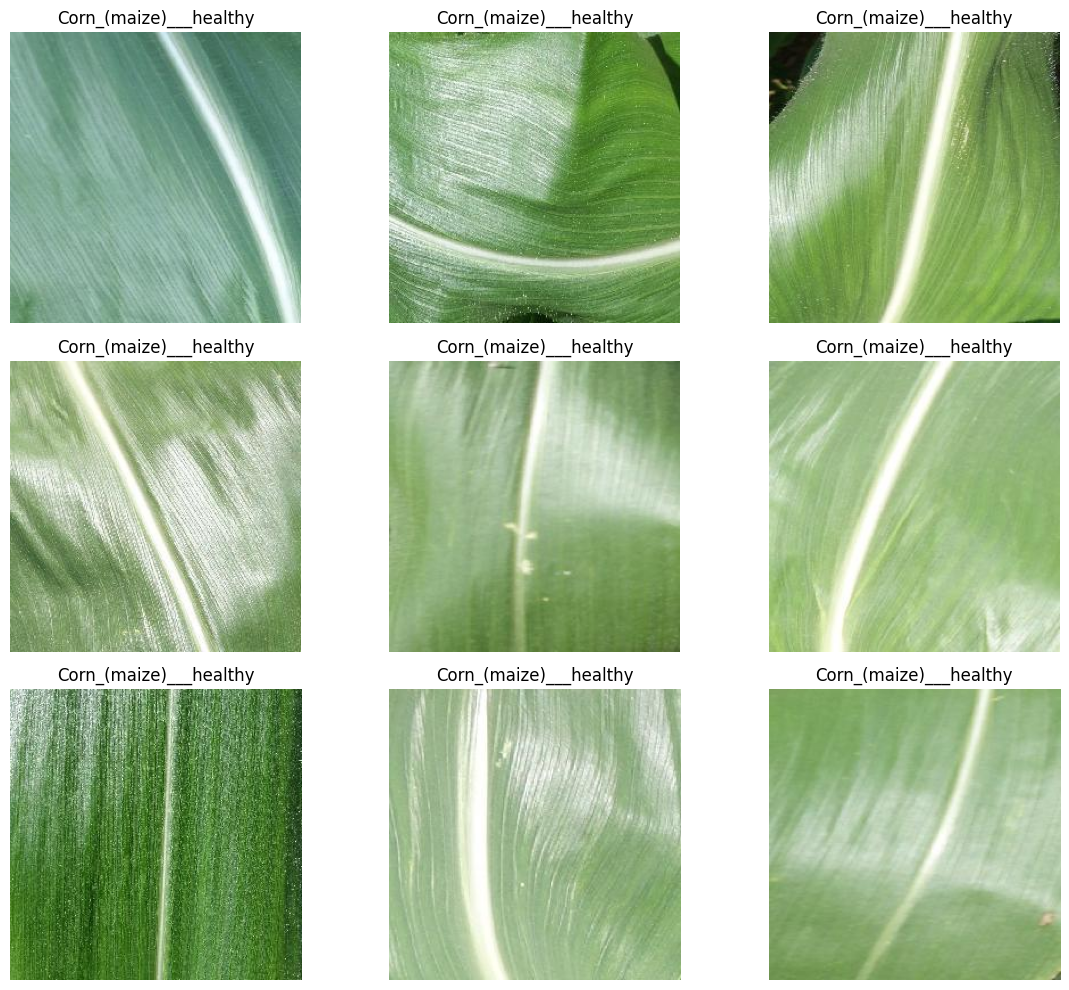

In [10]:
from matplotlib import pyplot as plt
from PIL import Image
import os

# Show firts 9 images
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

all_disease_classes = os.listdir(dataset_path)

disease_class_to_display = all_disease_classes[0]
class_path = os.path.join(dataset_path, disease_class_to_display)
images_in_class = os.listdir(class_path)[:9]

for i, img_name in enumerate(images_in_class):
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)

    row = i // 3
    col = i % 3
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(disease_class_to_display)

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = 'plant-disease-detection-dataset/Dataset'

datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'training'
)

# Validation
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'validation'
)
print(f"Training images: {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Disease classes: {train_data.num_classes}")

Found 28589 images belonging to 23 classes.
Found 7136 images belonging to 23 classes.
Training images: 28589
Validation images: 7136
Disease classes: 23


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load mobileNetV2 as base
base_model = MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Compile model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [14]:
# Train model
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 10,
)

print(f"Training complete!")

Epoch 1/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 973s 1s/step - accuracy: 0.8019 - loss: 0.6499 - val_accuracy: 0.9011 - val_loss: 0.2927
Epoch 2/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 958s 1s/step - accuracy: 0.8970 - loss: 0.3130 - val_accuracy: 0.9240 - val_loss: 0.2213
Epoch 3/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 960s 1s/step - accuracy: 0.9151 - loss: 0.2481 - val_accuracy: 0.9347 - val_loss: 0.1897
Epoch 4/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 992s 1s/step - accuracy: 0.9270 - loss: 0.2129 - val_accuracy: 0.9240 - val_loss: 0.2159
Epoch 5/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 978s 1s/step - accuracy: 0.9344 - loss: 0.1913 - val_accuracy: 0.9364 - val_loss: 0.1808
Epoch 6/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 983s 1s/step - accuracy: 0.9429 - loss: 0.1678 - val_accuracy: 0.9393 - val_loss: 0.1755
Epoch 7/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 1001s 1s/step - accuracy: 0.9477 - loss: 0.1512 - val_accuracy: 0.9437 - val_loss: 0.1695
Epoch 8/10
894/894 ━━━━━━━━━━━━━━━━━━━━ 1014s 1s/step - accuracy: 0.9505 - loss: 0.1405 - val_ac

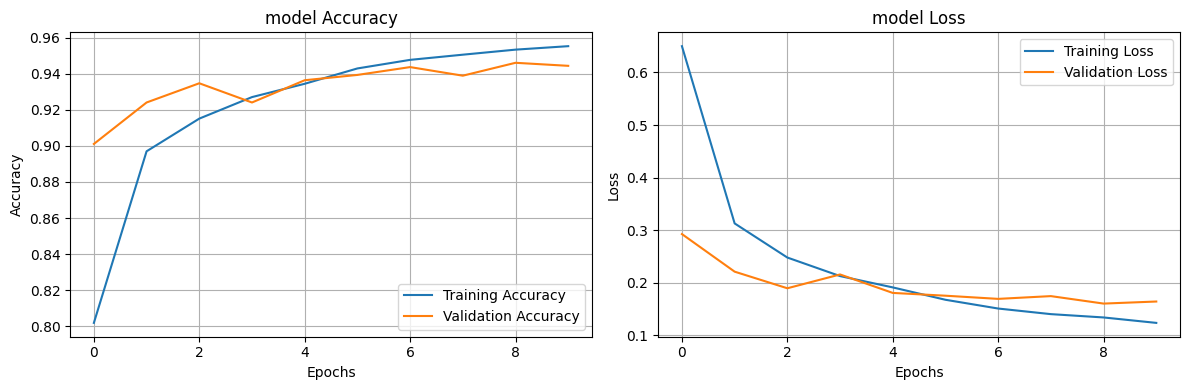

Final Training Accuracy: 0.9553
Final Validation Accuracy: 0.9444


In [15]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Print Final Result
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class: Corn_(maize)___healthy
confidence: 100.00%


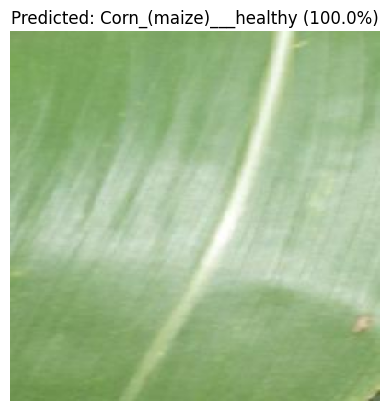

In [18]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt


# class names
classes = train_data.class_indices
class_names = {v: k for k, v in classes.items()}

# Test on images from validation data (corrected variable name)
test_data_path = 'plant-disease-detection-dataset/Dataset/Corn_(maize)___healthy/062b0c0f-94fa-4c58-b735-2ba65e4dc9b9___R.S_HL 7947 copy_flipLR.jpg'

# Load and process image (corrected function names and variable)
img = load_img(test_data_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

#Predict
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction)
confidence = prediction[0][predicted_class_index] * 100

print(f"Predicted class: {class_names[predicted_class_index]}")
print(f"confidence: {confidence:.2f}%")

# Show image
plt.imshow(img)
plt.title(f"Predicted: {class_names[predicted_class_index]} ({confidence:.1f}%)")
plt.axis('off')
plt.show()